In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# COMPARANDO CATEGORIAS

Os gráficos deste capítulo visam ajudar nossos leitores a comparar valores entre categorias. Barras, linhas e pontos permitem que os leitores façam comparações tanto dentro de grupos quanto entre eles. Em alguns casos, queremos que o leitor visualize tanto os níveis quanto as variações, ou alguma outra combinação de variáveis; em outros, queremos concentrar sua atenção em uma comparação específica.

O desafio ao comparar dados categóricos é decidir o que queremos que o gráfico transmita. Existe um argumento ou uma narrativa principal? Há algum aspecto que possa ser identificado como a comparação mais importante que se deseja que o leitor faça? Como criadores de gráficos, precisamos priorizar a função que queremos que eles desempenhem. Ao incluir todas as barras ou pontos no gráfico, podemos acabar obscurecendo a mensagem que desejamos transmitir.

Este capítulo começa com o gráfico de barras. Assim como o gráfico de linhas que dará início ao próximo capítulo, o gráfico de barras é familiar à maioria dos leitores, o que o torna uma escolha conveniente para orientá-los ao comparar categorias ou observar mudanças ao longo do tempo. Ele também ocupa o topo do diagrama de hierarquia de percepção visual. Não é obrigatório fornecer sempre os valores exatos aos leitores, mas, quando o fazemos, o gráfico de barras é uma excelente escolha.



 ## BARRAS EMPILHADAS

Outra variação do gráfico de barras é o gráfico de barras empilhadas. Enquanto o gráfico de barras agrupadas exibe dois ou mais valores de dados para cada categoria, este gráfico subdivide os dados dentro de cada categoria. As categorias podem somar um mesmo total — digamos, 100% —, de modo que o comprimento total da barra seja igual para todos os grupos. Por outro lado, os totais podem variar entre os grupos; nesse caso, o comprimento total de cada barra também pode variar. Acima, apresentei a parcela do Produto Interno Bruto (PIB) que cada um dos dez países dedica a programas de assistência à saúde, apoio à terceira idade e outras iniciativas. O comprimento total das barras indica quanto cada país gasta nesses programas em relação ao seu PIB.

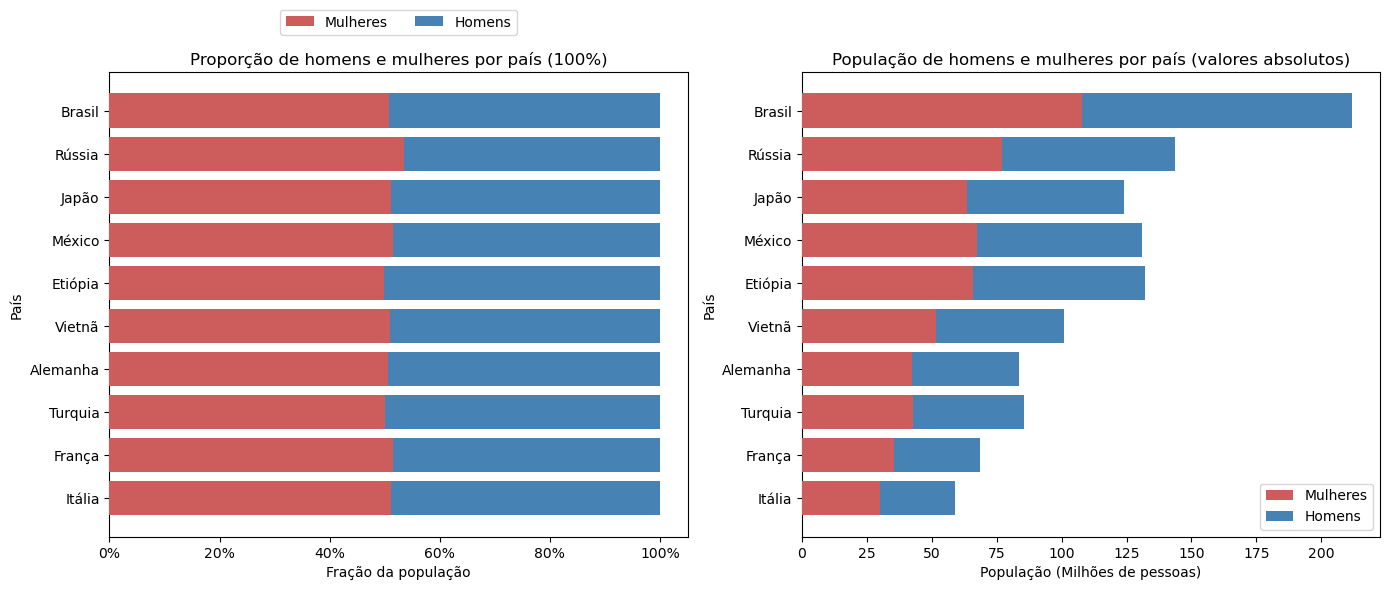

In [2]:
# Carregar os dados de população por sexo (números usam "." como separador de milhar)
data_sexo = pd.read_csv('../Data/populao-por-sexo-2024---world-bank.csv', thousands='.')

# Calcular as frações de homens e mulheres em relação ao total de cada país
total_populacao = data_sexo['Pop. Masculina'] + data_sexo['Pop. Feminina']
fracao_feminina = data_sexo['Pop. Feminina'] / total_populacao
fracao_masculina = data_sexo['Pop. Masculina'] / total_populacao

posicoes = np.arange(len(data_sexo))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --------------------------------------------------------------------------- #
# Esquerda: barras empilhadas em 100% (todas as barras com o mesmo comprimento)
# --------------------------------------------------------------------------- #
ax1.barh(posicoes, fracao_feminina, color='indianred', zorder=3, label='Mulheres')
ax1.barh(posicoes, fracao_masculina, left=fracao_feminina, color='steelblue',
         zorder=3, label='Homens')
ax1.invert_yaxis()

ax1.set_title('Proporção de homens e mulheres por país (100%)')
ax1.set_ylabel('País')
ax1.set_xlabel('Fração da população')
ax1.set_yticks(posicoes)
ax1.set_yticklabels(data_sexo['País'])
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x * 100)}%'))
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)

# --------------------------------------------------------------------------- #
# Direita: barras empilhadas com os valores absolutos (comprimento total varia)
# --------------------------------------------------------------------------- #
ax2.barh(posicoes, data_sexo['Pop. Feminina'], color='indianred', zorder=3, label='Mulheres')
ax2.barh(posicoes, data_sexo['Pop. Masculina'], left=data_sexo['Pop. Feminina'],
         color='steelblue', zorder=3, label='Homens')
ax2.invert_yaxis()

ax2.set_title('População de homens e mulheres por país (valores absolutos)')
ax2.set_ylabel('País')
ax2.set_xlabel('População (Milhões de pessoas)')
ax2.set_yticks(posicoes)
ax2.set_yticklabels(data_sexo['País'])
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x / 1e6)}'))
ax2.legend()

fig.tight_layout()
plt.show()

Assim como os gráficos de barras que analisamos até agora, o gráfico de barras empilhadas é familiar, fácil de ler e fácil de criar. O maior desafio, no entanto, é que pode ser difícil comparar os diferentes valores dos segmentos dentro do gráfico. No exemplo acima, é fácil comparar os valores entre os países para a categoria "Saúde", pois os segmentos das barras compartilham a mesma linha de base vertical. Mas isso é mais difícil de fazer com as outras duas séries, pois elas não compartilham uma linha de base. Qual país gasta mais com programas para a terceira idade: Itália ou Grécia? Percebe-se rapidamente que a Itália gasta mais com programas de saúde do que a Grécia, porque esses segmentos estão alinhados à esquerda no eixo vertical, mas é muito mais difícil determinar isso em relação aos segmentos das outras categorias.

Uma maneira de lidar com a linha de base variável é desmembrar o gráfico, de modo que cada série fique em sua própria linha de base vertical. Trata-se de um gráfico de múltiplos pequenos (*small multiples*), dispostos lado a lado. Agora fica mais fácil perceber que a Grécia gasta mais com programas voltados para a terceira idade do que a Itália. A contrapartida é que se torna mais difícil (ou até impossível) visualizar os valores totais. No entanto, isso também pode ser contornado: é possível desmembrar o gráfico de barras empilhadas e adicionar um segmento final que represente o valor total (isso não chega a ser um problema quando a soma de todas as séries resulta em 100%, pois todos os segmentos somados terão o mesmo comprimento).

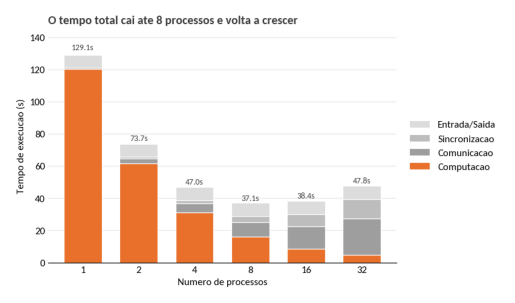

In [3]:
# Carregar a figura fig1_empilhado_totais_variáveis.png que está na sub pasta figures e mostrar com o imshow do matplotlib.pyplot
# Tirar os eixos e mostrar a figura com o plt.show()

img = mpimg.imread('figures/fig1_empilhado_totais_variaveis.png')
plt.imshow(img)
plt.axis('off')
plt.show()

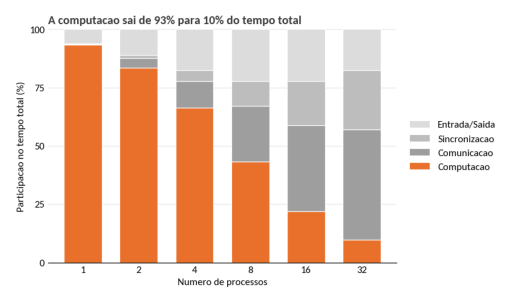

In [4]:
img = mpimg.imread('figures/fig2_empilhado_100_por_cento.png')
plt.imshow(img)
plt.axis('off')
plt.show()

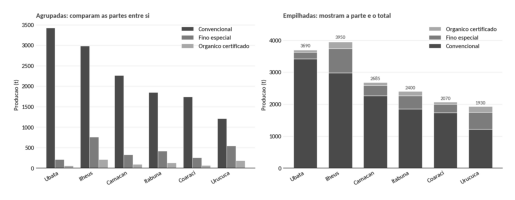

In [5]:
img = mpimg.imread('figures/fig3_agrupadas_vs_empilhadas.png')
plt.imshow(img)
plt.axis('off')
plt.show()

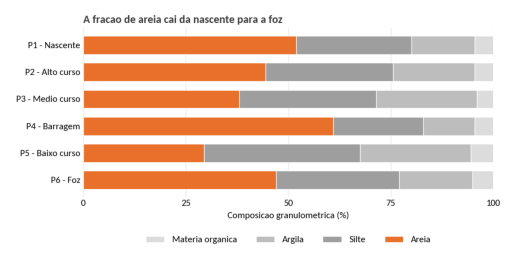

In [6]:
img = mpimg.imread('figures/fig4_empilhado_horizontal_100.png')
plt.imshow(img)
plt.axis('off')
plt.show()

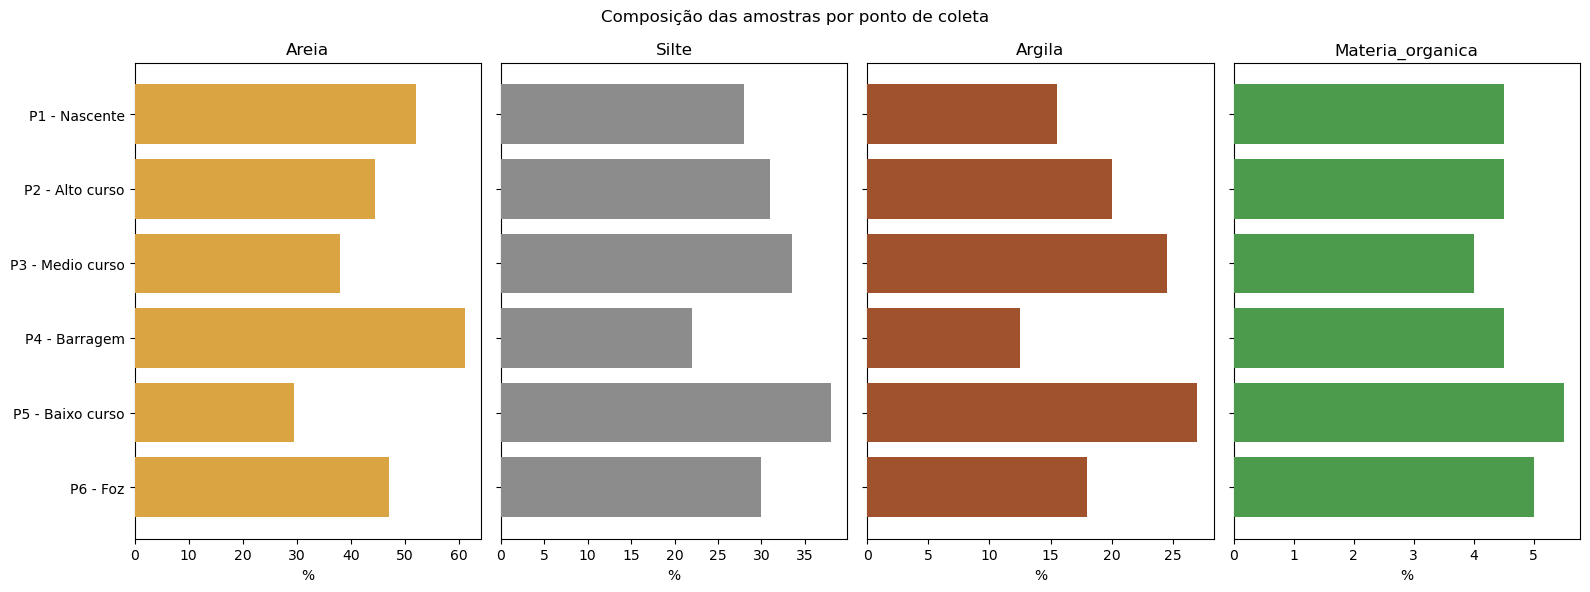

In [7]:
# Carregar os dados de composição das amostras por ponto de coleta
composicao = pd.read_csv('../Data/composicao_amostras.csv')

componentes = ['Areia', 'Silte', 'Argila', 'Materia_organica']
cores = ['#d9a441', '#8c8c8c', '#a0522d', '#4c9a4c']
posicoes = np.arange(len(composicao))

# Criar os múltiplos pequenos: um gráfico de barras (horizontais) por componente, lado a lado
fig, eixos = plt.subplots(1, len(componentes), figsize=(16, 6), sharey=True)

for ax, componente, cor in zip(eixos, componentes, cores):
    ax.barh(posicoes, composicao[componente], color=cor, zorder=3)
    ax.set_title(componente)
    ax.set_xlabel('%')

eixos[0].set_yticks(posicoes)
eixos[0].set_yticklabels(composicao['ponto_coleta'])
eixos[0].invert_yaxis()

fig.suptitle('Composição das amostras por ponto de coleta')
fig.tight_layout()
plt.show()

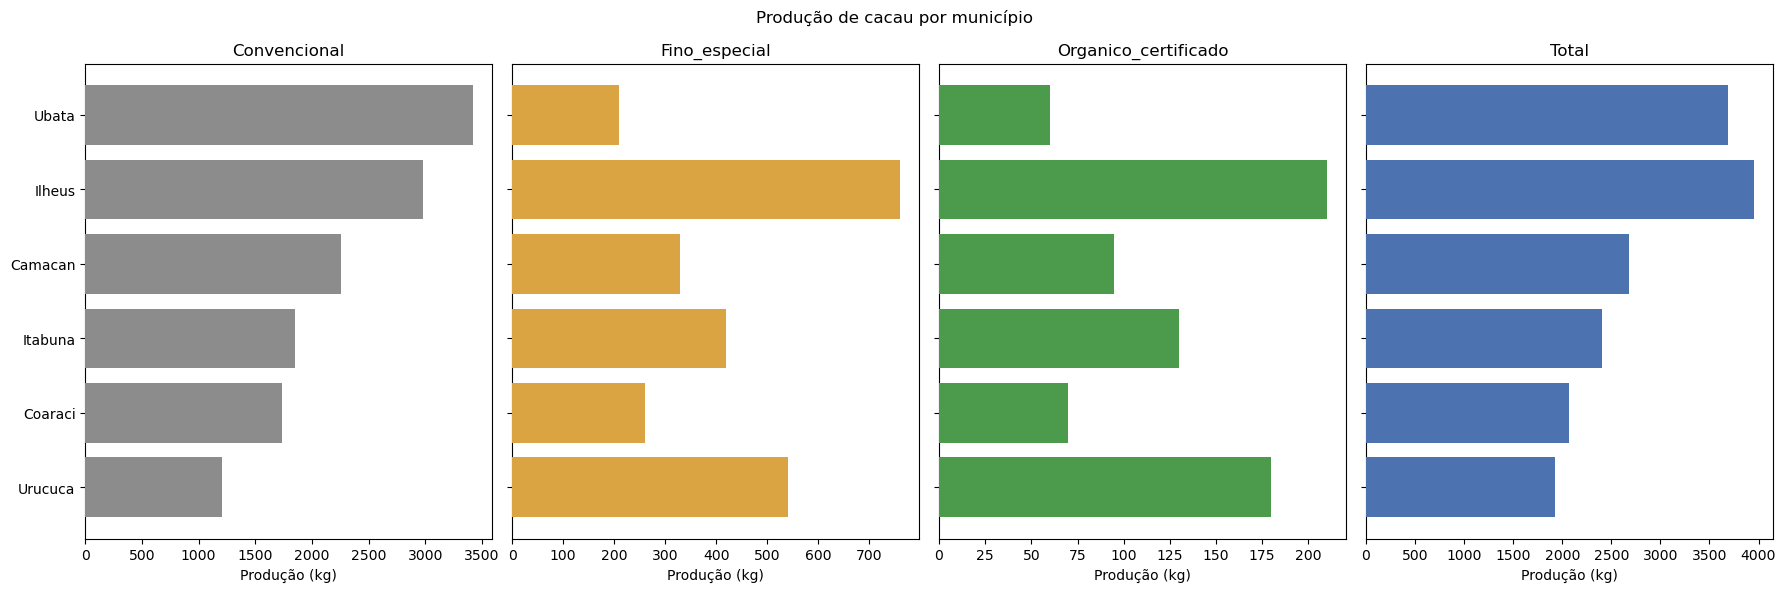

In [8]:
# Carregar os dados de produção de cacau por município
producao = pd.read_csv('../Data/producao_cacau_sintetico.csv')

tipos = ['Convencional', 'Fino_especial', 'Organico_certificado']
cores = ['#8c8c8c', '#d9a441', '#4c9a4c']
producao['Total'] = producao[tipos].sum(axis=1)
posicoes = np.arange(len(producao))

# Criar os múltiplos pequenos: um gráfico de barras (horizontais) por tipo, mais um com o total
fig, eixos = plt.subplots(1, len(tipos) + 1, figsize=(18, 6), sharey=True)

for ax, tipo, cor in zip(eixos, tipos, cores):
    ax.barh(posicoes, producao[tipo], color=cor, zorder=3)
    ax.set_title(tipo)
    ax.set_xlabel('Produção (kg)')

eixos[-1].barh(posicoes, producao['Total'], color='#4C72B0', zorder=3)
eixos[-1].set_title('Total')
eixos[-1].set_xlabel('Produção (kg)')

eixos[0].set_yticks(posicoes)
eixos[0].set_yticklabels(producao['municipio'])
eixos[0].invert_yaxis()

fig.suptitle('Produção de cacau por município')
fig.tight_layout()
plt.show()

Em ambas as versões, o espaçamento horizontal de cada segmento deve ter a mesma largura; caso contrário, pode parecer que um segmento ocupa uma proporção maior do espaço do que realmente ocupa. Nos casos em que você inclui o total, a largura não precisa ser igual à dos outros grupos, mas os intervalos ao longo do eixo devem ser os mesmos. Em outras palavras, se a largura de cada segmento — onde os dados variam de 0% a 50% — for de uma polegada, a categoria total, que abrange de 0% a 100%, deverá ter duas polegadas de largura.

Embora as diferentes linhas de base em um gráfico de barras empilhadas padrão possam dificultar a comparação de valores, há casos em que esse tipo de gráfico é preferível. Neste gráfico de barras empilhadas, incluí mais categorias de gastos e as dividi em proporções do total, de modo que o gráfico destaque a distribuição. Nessa visualização, fica claro que cerca de três quartos do gasto público total nesses países são destinados a programas de saúde e de assistência aos idosos. Essa observação é mais difícil de fazer na versão à direita, na qual cada categoria é posicionada em sua própria linha de base vertical. Embora seja mais fácil comparar as diferenças de cada categoria entre os países, não se observam grandes diferenças entre elas.

Como sempre, identifique o que você deseja mostrar e onde gostaria de concentrar a atenção do leitor. Nestes exemplos, a categoria Saúde é enfatizada porque os dados estão classificados de acordo com esses valores (apresentados como porcentagem do gasto total nesses programas específicos) e ela está posicionada ao longo da linha de base vertical. Nesse layout, os demais segmentos tornam-se secundários em relação aos gastos com saúde.

Existe um outro tipo de gráfico de barras empilhadas com o qual você talvez já tenha se deparado: aquele que mostra um único conjunto de valores de dados e a diferença entre eles e um outro valor (geralmente o total). O gráfico na página seguinte utiliza essa abordagem para exibir a proporção de mulheres eleitas para a Câmara dos Representantes dos EUA entre 1917 e 2018. A versão à esquerda apresenta as porcentagens brutas; o eixo vertical varia de 0 a 25 por cento. Nela, observa-se um aumento expressivo na participação feminina no Congresso. A versão à direita exibe os mesmos dados, mas acrescenta uma série cinza sobre os valores, completando o gráfico até a marca de 50 por cento. Essa versão permite enfatizar que a participação feminina ainda é reduzida, apesar de estar em crescimento. É justamente nessas situações — em que a proporção relativa é tão importante quanto a variação — que essa técnica pode ser particularmente valiosa.

### Variação percentual versus variação em pontos percentuais

Existe uma distinção importante entre variação percentual e variação em pontos percentuais, e esse é um erro que muitos costumam cometer.

A variação percentual compara um valor inicial (ANTIGO) a um valor final (NOVO) de acordo com esta fórmula simples: (Novo - Antigo) / Antigo × 100.

Variações percentuais positivas (ou seja, NOVO > ANTIGO) indicam um aumento percentual. Variações negativas (NOVO < ANTIGO) indicam uma queda. Você pode calcular diferenças ao longo do tempo ou entre grupos; o que realmente importa é seguir a fórmula e saber que está comparando a variação em relação ao valor inicial (ANTIGO).

A variação em pontos percentuais refere-se especificamente à análise de diferenças brutas entre porcentagens. A fórmula para essa variação é mais simples: Novo - Antigo, onde ambos já são porcentagens.

São coisas muito diferentes. Vamos tomar um exemplo simples. Segundo o Departamento do Censo dos EUA, havia 40,6 milhões de pessoas em situação de pobreza em 2016 e 39,6 milhões em 2017. A taxa de pobreza (o número de pessoas em situação de pobreza como porcentagem da população total) foi de 12,7% em 2016 e 12,3% em 2017.c

O número de pessoas em situação de pobreza caiu 2,3%. A variação percentual foi de

39,698,000 - 40,616,000)/40,616,000]×100 = [-0.023]×100 = -2.3%

Mas a taxa de pobreza caiu 0,4 ponto percentual ao longo dos dois anos:

12,3% - 12,7% = -0,4 ponto percentual

Obviamente, esses são dois números muito diferentes, mas as pessoas os confundem o tempo todo. Representar seus dados de forma clara começa por compreendê-los claramente — incluindo como foram coletados e como calcular estatísticas descritivas básicas.